In [1]:
import cobra

In [2]:
model_bs= cobra.io.read_sbml_model("/home/buttercup/Desktop/samraat/ibsu1147_bigg.xml")


In [3]:
model_bigg = cobra.io.read_sbml_model("/home/buttercup/Desktop/samraat/iYO844.xml")

In [ ]:
model_bs_witheps = cobra.io.read_sbml_model("/home/buttercup/Desktop/samraat/code/ibsu1147_with_eps.xml")

In [ ]:
(model_bs)

ibsu1147_bigg


In [5]:
#summary
print(model_bigg.summary())
print(model_bs.summary())   
print(model_bs_witheps.summary())

Objective
1.0 BIOMASS_BS_10 = 0.11796638932331775

Uptake
------
Metabolite    Reaction      Flux  C-Number  C-Flux
     ca2_e    EX_ca2_e 0.0003781         0   0.00%
     fe3_e    EX_fe3_e  0.000407         0   0.00%
  glc__D_e EX_glc__D_e       1.7         6 100.00%
       k_e      EX_k_e   0.08332         0   0.00%
     mg2_e    EX_mg2_e     0.012         0   0.00%
     nh4_e    EX_nh4_e     0.945         0   0.00%
      o2_e     EX_o2_e     5.706         0   0.00%
      pi_e     EX_pi_e    0.1811         0   0.00%
     so4_e    EX_so4_e   0.02009         0   0.00%

Secretion
---------
Metabolite Reaction    Flux  C-Number  C-Flux
     co2_e EX_co2_e  -5.981         1 100.00%
     h2o_e EX_h2o_e   -7.87         0   0.00%
       h_e   EX_h_e -0.7677         0   0.00%

Objective
1.0 bio00006 = 0.4115010020846017

Uptake
------
Metabolite    Reaction     Flux  C-Number C-Flux
     ca2_e    EX_ca2_e 0.001228         0  0.00%
    chor_e   EX_chor_e     1.83        10 37.89%
     fe3_e   

In [ ]:

solution = model_bs.optimize()
solution_bigg = model_bigg.optimize()
print(solution)
print(solution_bigg)
# Difference due to biomass objective?

<Solution 0.412 at 0x73ddf841b100>
<Solution 0.118 at 0x73ddf6024640>


In [7]:
solution = model_bs_witheps.optimize()
print(solution.objective_value)

0.41150100208460044


In [31]:
from cobra.flux_analysis import flux_variability_analysis
from cobra.flux_analysis.loopless import loopless_solution

fva_standard = flux_variability_analysis(model_bs, fraction_of_optimum=0.0, loopless=False)
fva_standard.to_csv("fva_standard.csv", index=True, index_label="reaction_id")

/tmp/ipykernel_7199/3687024754.py:4: DeprecationWarning: Passing a boolean value to the `loopless` argument is deprecated. Please pass either None, 'fastSNP' or 'cycleFreeFlux'.
  fva_standard = flux_variability_analysis(model_bs, fraction_of_optimum=0.0, loopless=False)


In [33]:

fva_loopless = flux_variability_analysis(model_bs, loopless=True)
fva_loopless.to_csv("fva_loopless_candidates.csv", index=True, index_label="reaction_id")

/tmp/ipykernel_7199/1193420233.py:1: DeprecationWarning: Passing a boolean value to the `loopless` argument is deprecated. Please pass either None, 'fastSNP' or 'cycleFreeFlux'.
  fva_loopless = flux_variability_analysis(model_bs, loopless=True)


KeyboardInterrupt: 

In [34]:
import pandas as pd

# Load your FVA results (or reuse fva_standard if it's still in memory)
fva_standard = pd.read_csv("fva_standard.csv", index_col="reaction_id")

fva_standard["range"] = fva_standard["maximum"] - fva_standard["minimum"]

# Flag reactions with range >= 999 (near full ±1000 bound width)
wide = fva_standard[fva_standard["range"] >= 999]

# Exclude exchange reactions (those starting with "EX_")
wide_internal = wide[~wide.index.str.startswith("EX_")]

# Get just the reaction ID list, for passing to loopless FVA
wide_internal_ids = wide_internal.index.tolist()

print(f"{len(wide_internal_ids)} internal reactions with wide flux ranges")
print(wide_internal_ids)

76 internal reactions with wide flux ranges
['PTAr', 'GLUDxi', 'r0074', 'ALATA_L', 'GLUR', 'ACKrh', 'MDHm', 'ASPTA', 'ALAD_L', 'ALAR', 'SUCOAS', 'OCOAT1', 'GLYCLTDym', 'ASPT', 'PSP_L', 'SPTix', 'TRPS2', 'P5CD', 'GLYCLTDx', 'SAGH', 'G3PD1ir', 'GLYK', 'DHFR', 'TPI', 'ALCD19', 'GAPDHf', 'GAPDi_nadp', 'FBAf', 'FUM', 'LLEUDr', 'LEUTAi', 'DGGH', 'RAFGH', 'ALATA_D', 'PBUTT', 'BUTCT', 'VALTA', 'PRO1xm', 'P5CR', 'R01253', 'R01365', 'HPYRRx', 'VALDHr', 'PGKm', 'PGCD', 'BUTKr', 'r0393', 'HSDxi', 'HSDy', 'HACD1i', 'HBCO_nadp', 'FRUK', 'TMDS', 'ILEDH2', 'ILETA', 'TRPS3', 'RAFH', 'BETALDHx', 'BETALDHy', 'FBA2', 'SERH', 'G6PIh', 'PGIA', 'G5SADrm', 'G6PI3', 'R03913', 'R03914', 'PSERT', 'R05133', 'NODOx', 'NODOy', 'TMDS3', 'NAt3_1', 'GLYt2r', 'AB6PGH', 'GLYt4']


In [35]:
from cobra.flux_analysis import flux_variability_analysis
import time

start = time.time()
fva_loopless = flux_variability_analysis(model, reaction_list=wide_internal_ids, loopless=True)
print(f"Took {time.time()-start:.1f}s")

fva_loopless.to_csv("fva_loopless_candidates.csv", index=True, index_label="reaction_id")

/tmp/ipykernel_7199/1384589147.py:5: DeprecationWarning: Passing a boolean value to the `loopless` argument is deprecated. Please pass either None, 'fastSNP' or 'cycleFreeFlux'.
  fva_loopless = flux_variability_analysis(model, reaction_list=wide_internal_ids, loopless=True)


KeyboardInterrupt: 

In [6]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [10]:
# Set the bounds of the exchange reactions in model_bs and model_bs_witheps to match those in model_bigg
model_bigg_o2_lb= (model_bigg.reactions.get_by_id("EX_o2_e")).lower_bound
model_bigg_glc_lb= (model_bigg.reactions.get_by_id("EX_glc__D_e")).lower_bound
model_bigg_o2_ub= (model_bigg.reactions.get_by_id("EX_o2_e")).upper_bound
model_bigg_glc_ub= (model_bigg.reactions.get_by_id("EX_glc__D_e")).upper_bound

model_bs.reactions.get_by_id("EX_o2_e").lower_bound = model_bigg_o2_lb
model_bs.reactions.get_by_id("EX_glc__D_e").lower_bound = model_bigg_glc_lb
model_bs.reactions.get_by_id("EX_o2_e").upper_bound = model_bigg_o2_ub
model_bs.reactions.get_by_id("EX_glc__D_e").upper_bound = model_bigg_glc_ub
model_bs_witheps.reactions.get_by_id("EX_o2_e").lower_bound = model_bigg_o2_lb
model_bs_witheps.reactions.get_by_id("EX_glc__D_e").lower_bound = model_bigg_glc_lb
model_bs_witheps.reactions.get_by_id("EX_o2_e").upper_bound = model_bigg_o2_ub
model_bs_witheps.reactions.get_by_id("EX_glc__D_e").upper_bound = model_bigg_glc_ub

In [7]:
uptake=np.arange(0.1, 10.1, 0.1) # Glucose uptake rates from 0.1 to 10 mmol/gDW/h
uptake=uptake.tolist()
print(uptake)
df=pd.DataFrame(columns=['glucose_uptake_mmol_gDW_h','oxygen_uptake_mmol_gDW_h'])
df['glucose_uptake_mmol_gDW_h'] = uptake
df['oxygen_uptake_mmol_gDW_h'] = uptake
def growth_uptake(model,rxn):
    model_name=str(model)
    rxn_name=rxn.id
    for rate in uptake:
        with model:  
            rxn.lower_bound = -rate
            rxn.upper_bound = 0
            sol = model.optimize()
            growth = sol.objective_value if sol.status == "optimal" else None
            df.at[uptake.index(rate),model_name+"_"+rxn_name+"_growth_rate_1_h"] = growth
            df.at[uptake.index(rate),"status"] = sol.status
    print(df)
    df.to_csv("growth_vs_glucose.csv", index=False)

        

[0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6, 0.7000000000000001, 0.8, 0.9, 1.0, 1.1, 1.2000000000000002, 1.3000000000000003, 1.4000000000000001, 1.5000000000000002, 1.6, 1.7000000000000002, 1.8000000000000003, 1.9000000000000001, 2.0, 2.1, 2.2, 2.3000000000000003, 2.4000000000000004, 2.5000000000000004, 2.6, 2.7, 2.8000000000000003, 2.9000000000000004, 3.0000000000000004, 3.1, 3.2, 3.3000000000000003, 3.4000000000000004, 3.5000000000000004, 3.6, 3.7, 3.8000000000000003, 3.9000000000000004, 4.0, 4.1, 4.2, 4.3, 4.3999999999999995, 4.5, 4.6, 4.7, 4.8, 4.9, 5.0, 5.1, 5.2, 5.3, 5.4, 5.5, 5.6, 5.7, 5.8, 5.9, 6.0, 6.1, 6.2, 6.3, 6.4, 6.5, 6.6, 6.7, 6.8, 6.9, 7.0, 7.1, 7.2, 7.3, 7.4, 7.5, 7.6, 7.7, 7.8, 7.9, 8.0, 8.1, 8.2, 8.3, 8.4, 8.5, 8.6, 8.7, 8.8, 8.9, 9.0, 9.1, 9.2, 9.3, 9.4, 9.5, 9.6, 9.700000000000001, 9.8, 9.9, 10.0]


In [22]:

growth_uptake(model_bs,rxn=model_bs.reactions.get_by_id("EX_glc__D_e"))
growth_uptake(model_bigg,rxn=model_bigg.reactions.get_by_id("EX_glc__D_e"))
growth_uptake(model_bs_witheps,rxn=model_bs_witheps.reactions.get_by_id("EX_glc__D_e"))

/home/buttercup/miniconda3/envs/gems311/lib/python3.13/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


    glucose_uptake_mmol_gDW_h  oxygen_uptake_mmol_gDW_h  \
0                         0.1                       0.1   
1                         0.2                       0.2   
2                         0.3                       0.3   
3                         0.4                       0.4   
4                         0.5                       0.5   
..                        ...                       ...   
95                        9.6                       9.6   
96                        9.7                       9.7   
97                        9.8                       9.8   
98                        9.9                       9.9   
99                       10.0                      10.0   

   ibsu1147_bigg_EX_glc__D_e_growth_rate_1_h      status  \
0                                       None  infeasible   
1                                       None  infeasible   
2                                    0.00221     optimal   
3                                   0.010918     op

/home/buttercup/miniconda3/envs/gems311/lib/python3.13/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


    glucose_uptake_mmol_gDW_h  oxygen_uptake_mmol_gDW_h  \
0                         0.1                       0.1   
1                         0.2                       0.2   
2                         0.3                       0.3   
3                         0.4                       0.4   
4                         0.5                       0.5   
..                        ...                       ...   
95                        9.6                       9.6   
96                        9.7                       9.7   
97                        9.8                       9.8   
98                        9.9                       9.9   
99                       10.0                      10.0   

   ibsu1147_bigg_EX_glc__D_e_growth_rate_1_h      status  \
0                                       None  infeasible   
1                                       None  infeasible   
2                                    0.00221  infeasible   
3                                   0.010918     op

/home/buttercup/miniconda3/envs/gems311/lib/python3.13/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


    glucose_uptake_mmol_gDW_h  oxygen_uptake_mmol_gDW_h  \
0                         0.1                       0.1   
1                         0.2                       0.2   
2                         0.3                       0.3   
3                         0.4                       0.4   
4                         0.5                       0.5   
..                        ...                       ...   
95                        9.6                       9.6   
96                        9.7                       9.7   
97                        9.8                       9.8   
98                        9.9                       9.9   
99                       10.0                      10.0   

   ibsu1147_bigg_EX_glc__D_e_growth_rate_1_h      status  \
0                                       None  infeasible   
1                                       None  infeasible   
2                                    0.00221     optimal   
3                                   0.010918     op

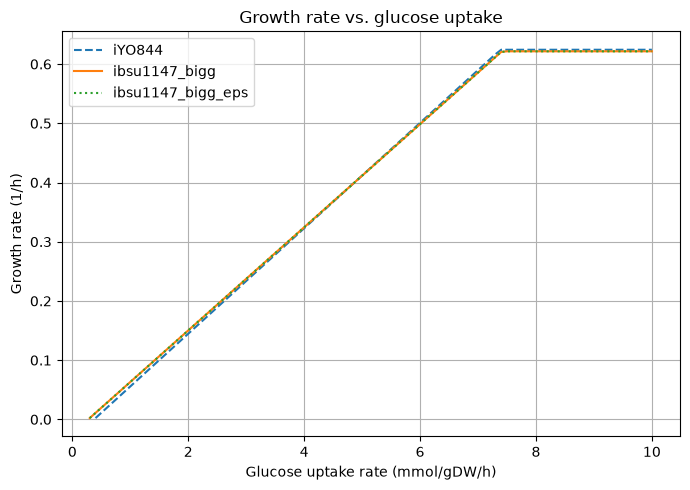

In [23]:

# Plot
plt.figure(figsize=(7, 5))
plt.plot(df["glucose_uptake_mmol_gDW_h"], df["iYO844_EX_glc__D_e_growth_rate_1_h"], linestyle="dashed")
plt.plot(df["glucose_uptake_mmol_gDW_h"], df["ibsu1147_bigg_EX_glc__D_e_growth_rate_1_h"], linestyle="solid")
plt.plot(df["glucose_uptake_mmol_gDW_h"], df["ibsu1147_bigg_eps_EX_glc__D_e_growth_rate_1_h"], linestyle="dotted")
plt.legend(["iYO844", "ibsu1147_bigg", "ibsu1147_bigg_eps"])
plt.xlabel("Glucose uptake rate (mmol/gDW/h)")
plt.ylabel("Growth rate (1/h)")
plt.title("Growth rate vs. glucose uptake")
plt.grid(True)
plt.tight_layout()
plt.savefig("growth_vs_glucose.png", dpi=150)
plt.show()

In [12]:
growth_uptake(model_bs,rxn=model_bs.reactions.get_by_id("EX_o2_e"))
growth_uptake(model_bigg,rxn=model_bigg.reactions.get_by_id("EX_o2_e"))
growth_uptake(model_bs_witheps,rxn=model_bs_witheps.reactions.get_by_id("EX_o2_e"))

    glucose_uptake_mmol_gDW_h  oxygen_uptake_mmol_gDW_h  \
0                         0.1                       0.1   
1                         0.2                       0.2   
2                         0.3                       0.3   
3                         0.4                       0.4   
4                         0.5                       0.5   
..                        ...                       ...   
95                        9.6                       9.6   
96                        9.7                       9.7   
97                        9.8                       9.8   
98                        9.9                       9.9   
99                       10.0                      10.0   

    ibsu1147_bigg_EX_o2_e_growth_rate_1_h   status  \
0                                0.028730  optimal   
1                                0.030590  optimal   
2                                0.032450  optimal   
3                                0.034311  optimal   
4                    

/home/buttercup/miniconda3/envs/gems311/lib/python3.13/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


    glucose_uptake_mmol_gDW_h  oxygen_uptake_mmol_gDW_h  \
0                         0.1                       0.1   
1                         0.2                       0.2   
2                         0.3                       0.3   
3                         0.4                       0.4   
4                         0.5                       0.5   
..                        ...                       ...   
95                        9.6                       9.6   
96                        9.7                       9.7   
97                        9.8                       9.8   
98                        9.9                       9.9   
99                       10.0                      10.0   

    ibsu1147_bigg_EX_o2_e_growth_rate_1_h      status  \
0                                0.028730  infeasible   
1                                0.030590  infeasible   
2                                0.032450  infeasible   
3                                0.034311  infeasible   
4     

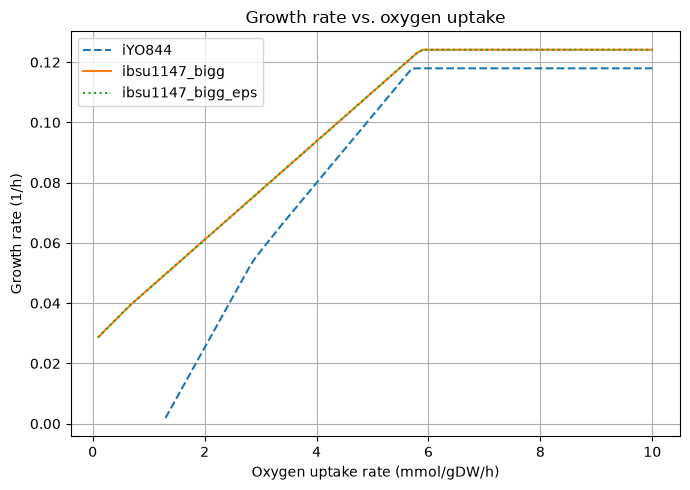

In [13]:

# Plot
plt.figure(figsize=(7, 5))
plt.plot(df["oxygen_uptake_mmol_gDW_h"], df["iYO844_EX_o2_e_growth_rate_1_h"], linestyle="dashed")
plt.plot(df["oxygen_uptake_mmol_gDW_h"], df["ibsu1147_bigg_EX_o2_e_growth_rate_1_h"], linestyle="solid")
plt.plot(df["oxygen_uptake_mmol_gDW_h"], df["ibsu1147_bigg_eps_EX_o2_e_growth_rate_1_h"], linestyle="dotted")
plt.legend(["iYO844", "ibsu1147_bigg", "ibsu1147_bigg_eps"])
plt.xlabel("Oxygen uptake rate (mmol/gDW/h)")
plt.ylabel("Growth rate (1/h)")
plt.title("Growth rate vs. oxygen uptake")
plt.grid(True)
plt.tight_layout()
plt.savefig("growth_vs_oxygen.png", dpi=150)
plt.show()

In [8]:
prod_env1 = cobra.flux_analysis.production_envelope(model_bs, ["EX_glc__D_e", "EX_o2_e"])



In [9]:
prod_env2= cobra.flux_analysis.production_envelope(model_bigg, ["EX_glc__D_e", "EX_o2_e"])

In [26]:
prod_env3= cobra.flux_analysis.production_envelope(model_bs_witheps, ["EX_glc__D_e", "EX_o2_e"])

Glucose exchange (EX_glc__D_e)  bounds: [-5.0, 1000.0]
Convention: negative lower bound = uptake (e.g. -10 means max uptake of 10 mmol/gDW/h)

Scan complete. Max EPS production: 2.2747 mmol/gDW/h at glucose uptake = 20.00 mmol/gDW/h


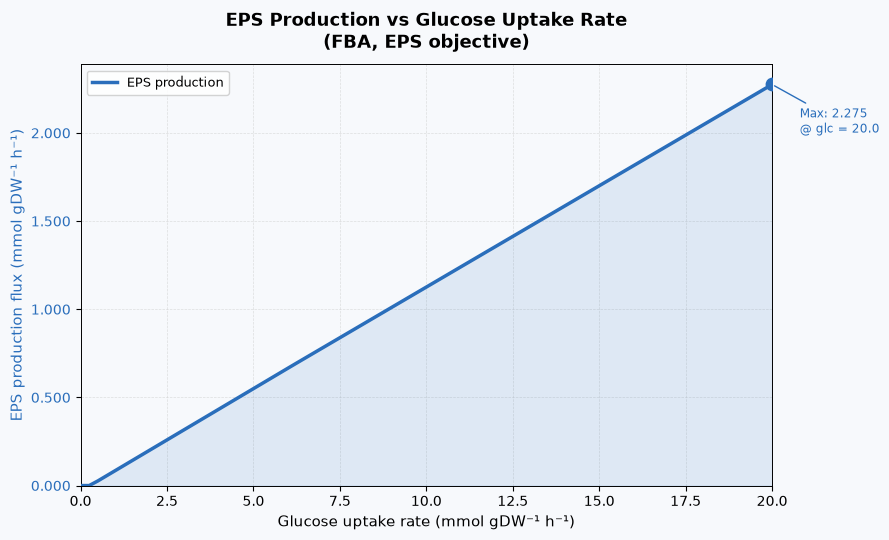


Plot saved → eps_vs_glucose.png

    Glucose uptake      EPS production     Growth rate
────────────────────────────────────────────────────────
              0.00              0.0000             n/a
              1.25              0.1135             n/a
              2.50              0.2589             n/a
              3.75              0.4043             n/a
              5.00              0.5497             n/a
              6.25              0.6949             n/a
              7.50              0.8385             n/a
              8.75              0.9821             n/a
             10.00              1.1258             n/a
             11.25              1.2694             n/a
             12.50              1.4130             n/a
             13.75              1.5566             n/a
             15.00              1.7003             n/a
             16.25              1.8439             n/a
             17.50              1.9875             n/a
             18.75           

In [5]:
"""
eps_vs_glucose.py
=================
Phenotypic Phase Plane (PhPP)-style analysis:
Vary glucose uptake rate → maximise EPS production at each step → plot.

Run AFTER your model already has the EPS pathway reactions added
(UDCPPBACT, BACGLCNACT, BACGALNACT, BACGALT, EPSSYNTH, DM_eps_c).

Assumes:
  - model is named `model_bs`
  - glucose exchange reaction ID is 'EX_glc__D_e'
    (change GLU_EXCHANGE_ID below if your model uses a different ID)
  - EPS demand reaction ID is 'DM_eps_c'
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# CONFIG — adjust these two IDs if your model uses different names
# ─────────────────────────────────────────────────────────────────────────────
GLU_EXCHANGE_ID = "EX_glc__D_e"   # glucose uptake exchange reaction
EPS_DEMAND_ID   = "DM_eps_c"      # EPS sink/demand reaction

# ── Quick validation ──────────────────────────────────────────────────────────
for rid in [GLU_EXCHANGE_ID, EPS_DEMAND_ID]:
    if rid not in model_bs_witheps.reactions:
        raise ValueError(
            f"Reaction '{rid}' not found in model.\n"
            f"Available exchange reactions:\n"
            + "\n".join(f"  {r.id}" for r in model_bs_witheps.exchanges)
        )

# ── Confirm default glucose uptake bound ─────────────────────────────────────
glu_rxn = model_bs_witheps.reactions.get_by_id(GLU_EXCHANGE_ID)
print(f"Glucose exchange ({GLU_EXCHANGE_ID})  "
      f"bounds: [{glu_rxn.lower_bound}, {glu_rxn.upper_bound}]")
print(f"Convention: negative lower bound = uptake "
      f"(e.g. -10 means max uptake of 10 mmol/gDW/h)\n")

# ─────────────────────────────────────────────────────────────────────────────
# SCAN: vary glucose uptake (0 → 20 mmol/gDW/h) and maximise EPS
# ─────────────────────────────────────────────────────────────────────────────
glucose_range  = np.linspace(0, 20, 81)   # 0.0 → 20.0 in steps of 0.25
eps_production = []
growth_rates   = []

eps_rxn  = model_bs_witheps.reactions.get_by_id(EPS_DEMAND_ID)

# identify biomass objective — store for growth rate retrieval
original_obj = model_bs_witheps.objective.to_json()
biomass_rxn_id = list(model_bs_witheps.objective.variables)[0].name if model_bs_witheps.objective.variables else None

for glu_uptake in glucose_range:
    with model_bs_witheps:
        # Fix glucose uptake to current scan value
        glu_rxn.lower_bound = -glu_uptake   # negative = uptake in COBRApy convention

        # Maximise EPS production
        model_bs_witheps.objective = eps_rxn
        sol = model_bs_witheps.optimize()

        if sol.status == "optimal":
            eps_production.append(sol.objective_value)
            # Also grab biomass flux (if biomass reaction exists in solution)
            if biomass_rxn_id and biomass_rxn_id in sol.fluxes:
                growth_rates.append(sol.fluxes[biomass_rxn_id])
            else:
                growth_rates.append(np.nan)
        else:
            eps_production.append(0.0)
            growth_rates.append(np.nan)

eps_production = np.array(eps_production)
growth_rates   = np.array(growth_rates)

print(f"Scan complete. Max EPS production: {eps_production.max():.4f} mmol/gDW/h "
      f"at glucose uptake = {glucose_range[eps_production.argmax()]:.2f} mmol/gDW/h")

# ─────────────────────────────────────────────────────────────────────────────
# PLOT
# ─────────────────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor("#F7F9FC")
ax1.set_facecolor("#F7F9FC")

# ── EPS production (primary y-axis) ──────────────────────────────────────────
color_eps = "#2A6EBB"
ax1.plot(glucose_range, eps_production,
         color=color_eps, linewidth=2.5, zorder=3, label="EPS production")
ax1.fill_between(glucose_range, eps_production,
                 alpha=0.12, color=color_eps, zorder=2)

# Mark the maximum EPS point
peak_idx = np.argmax(eps_production)
ax1.scatter(glucose_range[peak_idx], eps_production[peak_idx],
            color=color_eps, s=80, zorder=5)
ax1.annotate(
    f"Max: {eps_production[peak_idx]:.3f}\n@ glc = {glucose_range[peak_idx]:.1f}",
    xy=(glucose_range[peak_idx], eps_production[peak_idx]),
    xytext=(glucose_range[peak_idx] + 0.8, eps_production[peak_idx] * 0.88),
    fontsize=8.5, color=color_eps,
    arrowprops=dict(arrowstyle="-", color=color_eps, lw=1),
)

ax1.set_xlabel("Glucose uptake rate (mmol gDW⁻¹ h⁻¹)", fontsize=11)
ax1.set_ylabel("EPS production flux (mmol gDW⁻¹ h⁻¹)", fontsize=11, color=color_eps)
ax1.tick_params(axis="y", labelcolor=color_eps)
ax1.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f"))
ax1.set_xlim(0, 20)
ax1.set_ylim(bottom=0)

# ── Growth rate (secondary y-axis) — only plotted if biomass data exists ──────
color_growth = "#E07B39"
if not np.all(np.isnan(growth_rates)):
    ax2 = ax1.twinx()
    ax2.plot(glucose_range, growth_rates,
             color=color_growth, linewidth=1.8, linestyle="--",
             zorder=3, label="Growth rate")
    ax2.set_ylabel("Growth rate (h⁻¹)", fontsize=11, color=color_growth)
    ax2.tick_params(axis="y", labelcolor=color_growth)
    ax2.set_ylim(bottom=0)
    # combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2,
               loc="upper left", framealpha=0.85, fontsize=9)
else:
    ax1.legend(loc="upper left", framealpha=0.85, fontsize=9)

# ── Grid & spines ─────────────────────────────────────────────────────────────
ax1.grid(True, linestyle="--", linewidth=0.5, alpha=0.6, color="#CCCCCC")
for spine in ax1.spines.values():
    spine.set_linewidth(0.7)

# ── Title & layout ────────────────────────────────────────────────────────────
ax1.set_title("EPS Production vs Glucose Uptake Rate\n(FBA, EPS objective)",
              fontsize=13, fontweight="bold", pad=12)

plt.tight_layout()
plt.savefig("eps_vs_glucose.png", dpi=180, bbox_inches="tight")
plt.show()
print("\nPlot saved → eps_vs_glucose.png")

# ─────────────────────────────────────────────────────────────────────────────
# TABULAR SUMMARY (every 5th data point)
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{'Glucose uptake':>18}  {'EPS production':>18}  {'Growth rate':>14}")
print("─" * 56)
for i in range(0, len(glucose_range), 5):
    gr = f"{growth_rates[i]:.4f}" if not np.isnan(growth_rates[i]) else "   n/a"
    print(f"{glucose_range[i]:>18.2f}  {eps_production[i]:>18.4f}  {gr:>14}")

In [10]:
print(model_bs_witheps.objective)

Maximize
1.0*bio00006 - 1.0*bio00006_reverse_45381


Running biomass-constrained EPS scan...
Biomass fraction     Scan points    Max EPS (mmol/gDW/h)
──────────────────────────────────────────────────────────
  30% biomass         61             1.7500  (@ glc = 19.0)
  50% biomass         61             1.2500  (@ glc = 16.3)
  70% biomass         61             0.7500  (@ glc = 16.3)
  90% biomass         61             0.2500  (@ glc = 11.7)


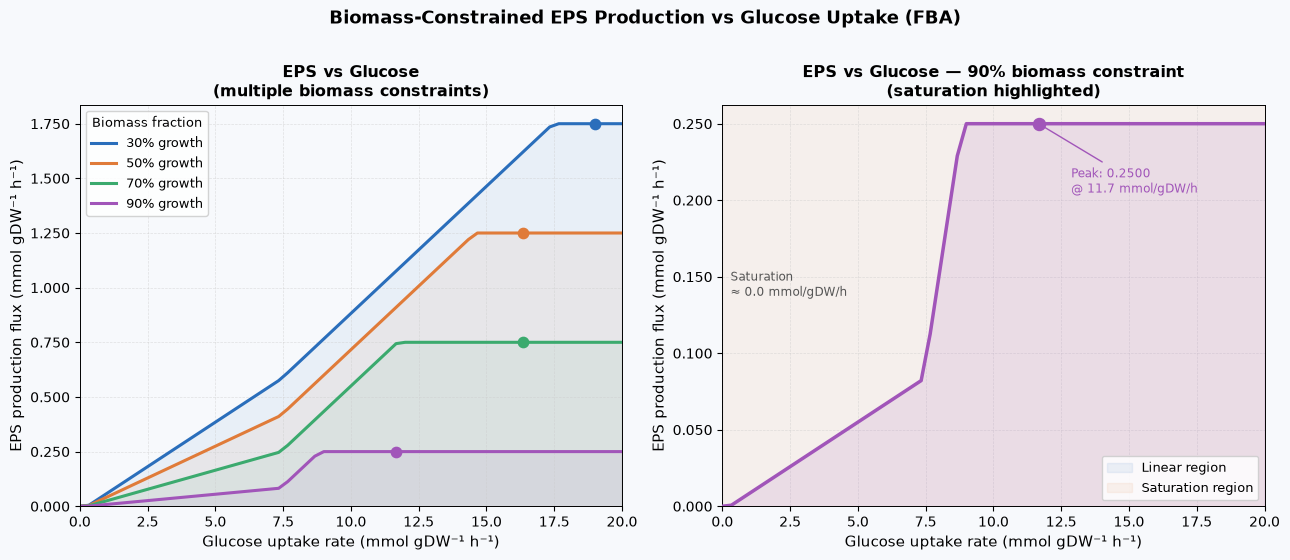


Plot saved → eps_vs_glucose_constrained.png

Summary — 90% biomass constraint
    Glucose (mmol/gDW/h)      EPS (mmol/gDW/h)
────────────────────────────────────────────────
                    0.00               0.00000
                    1.67               0.01619
                    3.33               0.03558
                    5.00               0.05497
                    6.67               0.07435
                    8.33               0.19020
                   10.00               0.25000
                   11.67               0.25000
                   13.33               0.25000
                   15.00               0.25000
                   16.67               0.25000
                   18.33               0.25000
                   20.00               0.25000


In [12]:
"""
eps_vs_glucose_biomass_constrained.py
======================================
Realistic EPS production vs glucose uptake curve using a two-step FBA:

  Step 1 → Maximise biomass at each glucose uptake rate
  Step 2 → Lock biomass at X% of its maximum, then maximise EPS

This forces glucose to be shared between growth and EPS biosynthesis,
creating the precursor bottleneck that causes realistic saturation.

Requires: model_bs with EPS pathway and DM_eps_c already added.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────────────────────
GLU_EXCHANGE_ID  = "EX_glc__D_e"   # glucose uptake exchange reaction ID
EPS_DEMAND_ID    = "DM_eps_c"       # EPS sink reaction ID
BIOMASS_RXN_ID   = "bio00006"  # ← change to your biomass reaction ID
                                     # (run: print([r.id for r in model_bs.reactions if "biomass" in r.id.lower()])
                                     #  to find yours)

BIOMASS_FRACTIONS = [0.3, 0.5, 0.7, 0.9]  # fractions of max growth to lock in
GLUCOSE_MAX       = 20.0   # mmol/gDW/h — upper end of scan
N_POINTS          = 61     # number of scan points

# Palette — one colour per biomass fraction
COLOURS = ["#2A6EBB", "#E07B39", "#3BAA6E", "#A155B9"]

glu_rxn     = model_bs_witheps.reactions.get_by_id(GLU_EXCHANGE_ID)
eps_rxn     = model_bs_witheps.reactions.get_by_id(EPS_DEMAND_ID)
biomass_rxn = model_bs_witheps.reactions.get_by_id(BIOMASS_RXN_ID)

glucose_range = np.linspace(0, GLUCOSE_MAX, N_POINTS)

# ─────────────────────────────────────────────────────────────────────────────
# SCAN
# ─────────────────────────────────────────────────────────────────────────────
print("Running biomass-constrained EPS scan...")
print(f"{'Biomass fraction':<20} {'Scan points':<14} {'Max EPS (mmol/gDW/h)'}")
print("─" * 58)

results = {}   # {fraction: np.array of EPS fluxes}

for fraction in BIOMASS_FRACTIONS:
    eps_vals    = []
    max_growth_vals = []

    for glu_uptake in glucose_range:
        with model_bs_witheps:
            glu_rxn.lower_bound = -glu_uptake

            # ── Step 1: maximise biomass ──────────────────────────────
            model_bs_witheps.objective = biomass_rxn
            sol_growth = model_bs_witheps.optimize()

            if sol_growth.status != "optimal" or sol_growth.objective_value <= 0:
                eps_vals.append(0.0)
                continue

            max_growth = sol_growth.objective_value

            # ── Step 2: constrain NET biomass (the actual obj expression)
            #           then maximise EPS ──────────────────────────────
            biomass_constraint = model_bs_witheps.problem.Constraint(
                model_bs_witheps.objective.expression,   # = bio00006 - bio00006_reverse_45381
                lb=fraction * max_growth,
                name="biomass_floor"
            )
            model_bs_witheps.add_cons_vars(biomass_constraint)

            model_bs_witheps.objective = eps_rxn
            sol_eps = model_bs_witheps.optimize()

            eps_vals.append(sol_eps.objective_value if sol_eps.status == "optimal" else 0.0)

    results[fraction] = np.array(eps_vals)
    peak = results[fraction].max()
    peak_glc = glucose_range[results[fraction].argmax()]
    print(f"  {fraction*100:.0f}% biomass         {N_POINTS:<14} "
          f"{peak:.4f}  (@ glc = {peak_glc:.1f})")

# ─────────────────────────────────────────────────────────────────────────────
# PLOT
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.patch.set_facecolor("#F7F9FC")

# ── Panel A: all fractions overlaid ──────────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#F7F9FC")

for (fraction, eps_vals), colour in zip(results.items(), COLOURS):
    ax1.plot(glucose_range, eps_vals,
             color=colour, linewidth=2.2, label=f"{int(fraction*100)}% growth")
    ax1.fill_between(glucose_range, eps_vals, alpha=0.07, color=colour)

    # Annotate peak
    peak_idx = np.argmax(eps_vals)
    if eps_vals[peak_idx] > 0:
        ax1.scatter(glucose_range[peak_idx], eps_vals[peak_idx],
                    color=colour, s=55, zorder=5)

ax1.set_xlabel("Glucose uptake rate (mmol gDW⁻¹ h⁻¹)", fontsize=10.5)
ax1.set_ylabel("EPS production flux (mmol gDW⁻¹ h⁻¹)", fontsize=10.5)
ax1.set_title("EPS vs Glucose\n(multiple biomass constraints)", fontsize=11.5,
              fontweight="bold")
ax1.legend(title="Biomass fraction", fontsize=9, title_fontsize=9,
           framealpha=0.85, loc="upper left")
ax1.set_xlim(0, GLUCOSE_MAX)
ax1.set_ylim(bottom=0)
ax1.grid(True, linestyle="--", linewidth=0.5, alpha=0.55, color="#CCCCCC")
ax1.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f"))
for spine in ax1.spines.values():
    spine.set_linewidth(0.7)

# ── Panel B: 90% fraction with saturation annotation ─────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#F7F9FC")

target_fraction = 0.9
eps_90 = results[target_fraction]
colour_90 = COLOURS[BIOMASS_FRACTIONS.index(target_fraction)]

ax2.plot(glucose_range, eps_90, color=colour_90, linewidth=2.5, zorder=3)
ax2.fill_between(glucose_range, eps_90, alpha=0.12, color=colour_90, zorder=2)

# Detect approximate saturation point (where marginal gain < 1% of peak per step)
peak_val = eps_90.max()
peak_idx = np.argmax(eps_90)
if N_POINTS > 1 and peak_val > 0:
    marginal = np.diff(eps_90) / (glucose_range[1] - glucose_range[0])
    sat_threshold = 0.01 * peak_val
    sat_candidates = np.where(marginal < sat_threshold)[0]
    sat_idx = sat_candidates[0] if len(sat_candidates) > 0 else peak_idx

    # Shade linear region
    ax2.axvspan(0, glucose_range[sat_idx], alpha=0.08, color="#2A6EBB",
                label="Linear region")
    # Shade saturation region
    ax2.axvspan(glucose_range[sat_idx], GLUCOSE_MAX, alpha=0.08, color="#E07B39",
                label="Saturation region")

    ax2.axvline(glucose_range[sat_idx], color="#888888", linestyle=":",
                linewidth=1.4)
    ax2.text(glucose_range[sat_idx] + 0.3,
             peak_val * 0.55,
             f"Saturation\n≈ {glucose_range[sat_idx]:.1f} mmol/gDW/h",
             fontsize=8.5, color="#555555")

# Peak annotation
ax2.scatter(glucose_range[peak_idx], peak_val, color=colour_90, s=75, zorder=6)
ax2.annotate(
    f"Peak: {peak_val:.4f}\n@ {glucose_range[peak_idx]:.1f} mmol/gDW/h",
    xy=(glucose_range[peak_idx], peak_val),
    xytext=(glucose_range[peak_idx] + 1.2, peak_val * 0.82),
    fontsize=8.5, color=colour_90,
    arrowprops=dict(arrowstyle="-", color=colour_90, lw=1.0),
)

ax2.set_xlabel("Glucose uptake rate (mmol gDW⁻¹ h⁻¹)", fontsize=10.5)
ax2.set_ylabel("EPS production flux (mmol gDW⁻¹ h⁻¹)", fontsize=10.5)
ax2.set_title("EPS vs Glucose — 90% biomass constraint\n(saturation highlighted)",
              fontsize=11.5, fontweight="bold")
ax2.legend(fontsize=9, framealpha=0.85, loc="lower right")
ax2.set_xlim(0, GLUCOSE_MAX)
ax2.set_ylim(bottom=0)
ax2.grid(True, linestyle="--", linewidth=0.5, alpha=0.55, color="#CCCCCC")
ax2.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f"))
for spine in ax2.spines.values():
    spine.set_linewidth(0.7)

plt.suptitle("Biomass-Constrained EPS Production vs Glucose Uptake (FBA)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("eps_vs_glucose_constrained.png", dpi=180, bbox_inches="tight")
plt.show()
print("\nPlot saved → eps_vs_glucose_constrained.png")

# ─────────────────────────────────────────────────────────────────────────────
# SUMMARY TABLE (90% fraction, every 5th point)
# ─────────────────────────────────────────────────────────────────────────────
print(f"\nSummary — 90% biomass constraint")
print(f"{'Glucose (mmol/gDW/h)':>24}  {'EPS (mmol/gDW/h)':>20}")
print("─" * 48)
for i in range(0, N_POINTS, 5):
    print(f"{glucose_range[i]:>24.2f}  {results[0.9][i]:>20.5f}")

In [3]:
model_bs_lb= cobra.io.read_sbml_model("/home/buttercup/Desktop/samraat/new_model.xml")

Adding exchange reaction EX_h2o_e with default bounds for boundary metabolite: h2o_e.
Adding exchange reaction EX_o2_e with default bounds for boundary metabolite: o2_e.
Adding exchange reaction EX_pi_e with default bounds for boundary metabolite: pi_e.
Adding exchange reaction EX_co2_e with default bounds for boundary metabolite: co2_e.
Adding exchange reaction EX_ppi_e with default bounds for boundary metabolite: ppi_e.
Adding exchange reaction EX_nh4_e with default bounds for boundary metabolite: nh4_e.
Adding exchange reaction EX_amp_e with default bounds for boundary metabolite: amp_e.
Adding exchange reaction EX_pyr_e with default bounds for boundary metabolite: pyr_e.
Adding exchange reaction EX_glu__L_e with default bounds for boundary metabolite: glu__L_e.
Adding exchange reaction EX_akg_e with default bounds for boundary metabolite: akg_e.
Adding exchange reaction EX_pheme_e with default bounds for boundary metabolite: pheme_e.
Adding exchange reaction EX_ac_e with default bo

In [ ]:
model_bs_lb.optimize()